202년 아파트 거래 자료 - 실습

In [ ]:
# %pip install pandas
# %pip install numpy
# %install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
UsageError: Line magic function `%install` not found.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('../data/trade_apt_api_2023_address.txt', sep="\t")
df

,기준년월,지역명,지역코드,법정동,아파트,거래금액,년,월,일,건축년도,전용면적,지번,층
0,202306,종로구,11110,사직동,광화문스페이스본(101동~105동),"138,000",2023,6,9,2008,95.880,9,9
1,202306,종로구,11110,사직동,광화문스페이스본(101동~105동),"170,000",2023,6,10,2008,146.920,9,8
2,202306,종로구,11110,사직동,사직아파트,"84,000",2023,6,12,1970,116.230,1-8,6
3,202306,종로구,11110,당주동,롯데미도파광화문빌딩,"93,000",2023,6,20,1981,149.950,145,9
4,202306,종로구,11110,신문로2가,디팰리스,"408,000",2023,6,24,2020,148.111,171,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2297,202201,강남구,11680,도곡동,현대비젼21,"50,000",2022,1,14,1999,35.480,467-19,20
2298,202201,강남구,11680,도곡동,삼성,"220,000",2022,1,15,1994,84.910,161,5
2299,202201,강남구,11680,도곡동,SK허브프리모,"37,400",2022,1,18,2006,33.800,953-1,8
2300,202201,강남구,11680,도곡동,한신(개포),"281,000",2022,1,23,1985,83.860,464,5


In [83]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2302 entries, 0 to 2301
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   기준년월    2302 non-null   int64  
 1   지역명     2302 non-null   str    
 2   지역코드    2302 non-null   int64  
 3   법정동     2302 non-null   str    
 4   아파트     2302 non-null   str    
 5   거래금액    2302 non-null   str    
 6   년       2302 non-null   int64  
 7   월       2302 non-null   int64  
 8   일       2302 non-null   int64  
 9   건축년도    2302 non-null   int64  
 10  전용면적    2302 non-null   float64
 11  지번      2302 non-null   str    
 12  층       2302 non-null   int64  
dtypes: float64(1), int64(7), str(5)
memory usage: 233.9 KB


In [84]:
df.describe()

,기준년월,지역코드,년,월,일,건축년도,전용면적,층
count,2302.000000,2302.000000,2302.000000,2302.000000,2302.000000,2302.000000,2302.000000,2302.000000
mean,202261.738923,11607.697654,2022.571242,4.614683,16.168115,2001.136838,81.173045,9.668983
std,48.717547,189.737573,0.495006,2.474663,8.576874,12.163308,46.020959,7.153552
min,202201.000000,11110.000000,2022.000000,1.000000,1.000000,1966.000000,12.010000,-1.000000
25%,202206.000000,11680.000000,2022.000000,3.000000,9.000000,1992.000000,49.460475,5.000000
50%,202302.000000,11680.000000,2023.000000,4.000000,16.000000,2003.000000,80.130000,8.000000
75%,202304.000000,11680.000000,2023.000000,6.000000,23.000000,2011.000000,101.988550,13.000000
max,202306.000000,11680.000000,2023.000000,12.000000,31.000000,2023.000000,301.470000,64.000000


In [85]:
df['거래금액']

0            138,000
1            170,000
2             84,000
3             93,000
4            408,000
            ...     
2297          50,000
2298         220,000
2299          37,400
2300         281,000
2301         420,000
Name: 거래금액, Length: 2302, dtype: str

In [86]:
price = '135,000'.replace(',', '')
price

'135000'

In [126]:
print(type(price))

<class 'str'>


In [127]:
iprice = int(price)
print(type(iprice))

<class 'int'>


In [87]:
df['거래금액'].replace(',', '')

0            138,000
1            170,000
2             84,000
3             93,000
4            408,000
            ...     
2297          50,000
2298         220,000
2299          37,400
2300         281,000
2301         420,000
Name: 거래금액, Length: 2302, dtype: str

In [88]:
print(type(price))

<class 'str'>


In [89]:
iprice = int(price)
print(type(iprice))

<class 'int'>


In [90]:
# 거래금액이 "1,234" 와 같은 문자열이면 숫자연산 차트 불가함 -> 전처리 필요
# .replace(',', ''): 천 단위 구분 쉼표 제거 -> '1,234'-> '1234'
# .astype(int): 문자열을 정수형으로 변환 -> 이후에 합계, 평균, 그래프에서 사용
df["거래금액"] = df["거래금액"].str.replace(',','').astype(int)

In [91]:
print(type(df['거래금액']))

<class 'pandas.Series'>


In [92]:
df['거래금액']

0       138000
1       170000
2        84000
3        93000
4       408000
         ...  
2297     50000
2298    220000
2299     37400
2300    281000
2301    420000
Name: 거래금액, Length: 2302, dtype: int64

In [108]:
df

,기준년월,지역명,지역코드,법정동,아파트,거래금액,년,월,일,건축년도,전용면적,지번,층
0,202306,종로구,11110,사직동,광화문스페이스본(101동~105동),138000,2023,6,9,2008,95.880,9,9
1,202306,종로구,11110,사직동,광화문스페이스본(101동~105동),170000,2023,6,10,2008,146.920,9,8
2,202306,종로구,11110,사직동,사직아파트,84000,2023,6,12,1970,116.230,1-8,6
3,202306,종로구,11110,당주동,롯데미도파광화문빌딩,93000,2023,6,20,1981,149.950,145,9
4,202306,종로구,11110,신문로2가,디팰리스,408000,2023,6,24,2020,148.111,171,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2297,202201,강남구,11680,도곡동,현대비젼21,50000,2022,1,14,1999,35.480,467-19,20
2298,202201,강남구,11680,도곡동,삼성,220000,2022,1,15,1994,84.910,161,5
2299,202201,강남구,11680,도곡동,SK허브프리모,37400,2022,1,18,2006,33.800,953-1,8
2300,202201,강남구,11680,도곡동,한신(개포),281000,2022,1,23,1985,83.860,464,5


In [107]:
df.describe()

,기준년월,지역코드,거래금액,년,월,일,건축년도,전용면적,층
count,2302.000000,2302.000000,2.302000e+03,2302.000000,2302.000000,2302.000000,2302.000000,2302.000000,2302.000000
mean,202261.738923,11607.697654,1.919084e+05,2022.571242,4.614683,16.168115,2001.136838,81.173045,9.668983
std,48.717547,189.737573,1.315151e+05,0.495006,2.474663,8.576874,12.163308,46.020959,7.153552
min,202201.000000,11110.000000,9.500000e+03,2022.000000,1.000000,1.000000,1966.000000,12.010000,-1.000000
25%,202206.000000,11680.000000,9.600000e+04,2022.000000,3.000000,9.000000,1992.000000,49.460475,5.000000
50%,202302.000000,11680.000000,1.800000e+05,2023.000000,4.000000,16.000000,2003.000000,80.130000,8.000000
75%,202304.000000,11680.000000,2.527500e+05,2023.000000,6.000000,23.000000,2011.000000,101.988550,13.000000
max,202306.000000,11680.000000,1.450000e+06,2023.000000,12.000000,31.000000,2023.000000,301.470000,64.000000


In [95]:
df.shape

(2302, 13)

In [106]:
df_cnt = df.groupby('기준년월').count()['거래금액']
df_cnt

기준년월
202201     76
202202     85
202203    114
202204    139
202205    136
202206     84
202207     70
202208    113
202209     48
202210     35
202211     38
202212     49
202301    113
202302    214
202303    211
202304    216
202305    291
202306    270
Name: 거래금액, dtype: int64

In [97]:
x1 = df_cnt.values
x1

array([ 76,  85, 114, 139, 136,  84,  70, 113,  48,  35,  38,  49, 113,
       214, 211, 216, 291, 270])

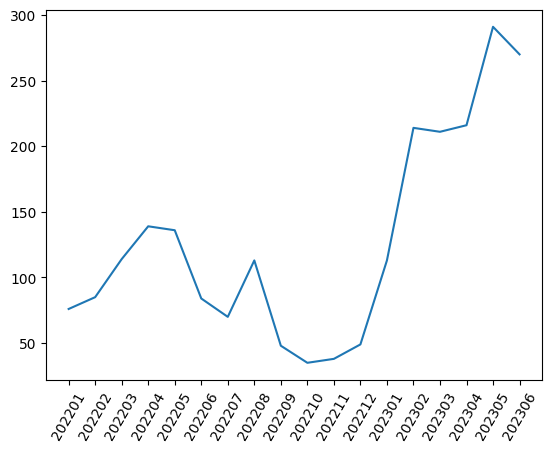

In [98]:
# x축  눈금 위치에 df_cnt.index(기준년월) 라벨로 표시
plt.xticks(np.arange(len(df_cnt.index)), labels=df_cnt.index)
# x출 라벨이 길면 겹쳐서 60도 기울기 줌
plt.tick_params(axis='x', labelrotation=60)
# x1데이터를 선 그래프로 그림
plt.plot(x1)
plt.show()

통계분석이나 수치계산을 위해 select_dtypes함수가 제공됨

In [105]:
df_num = df.select_dtypes(include=np.number)
df_num.head(5)

,기준년월,지역코드,거래금액,년,월,일,건축년도,전용면적,층
0,202306,11110,138000,2023,6,9,2008,95.880,9
1,202306,11110,170000,2023,6,10,2008,146.920,8
2,202306,11110,84000,2023,6,12,1970,116.230,6
3,202306,11110,93000,2023,6,20,1981,149.950,9
4,202306,11110,408000,2023,6,24,2020,148.111,10


문제: 거래 금액에 대한 기준년월별 평균 거래 금액을 출력하시오

In [104]:
df_mean = df_num.groupby('기준년월').mean()['거래금액']
df_mean

기준년월
202201    178784.907895
202202    176651.564706
202203    197273.245614
202204    232832.446043
202205    208996.691176
202206    213556.690476
202207    196403.571429
202208     94087.318584
202209    142999.937500
202210    160898.142857
202211    203631.578947
202212    163493.877551
202301    168342.123894
202302    167463.177570
202303    199844.976303
202304    216480.601852
202305    195190.343643
202306    217566.666667
Name: 거래금액, dtype: float64

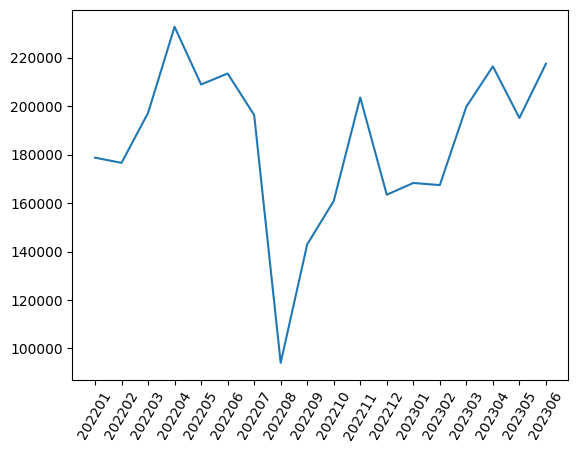

In [128]:
x2 = df_mean.values
x2

plt.xticks(np.arange(len(df_cnt.index)), labels=df_cnt.index)
# x축 라벨 회전하기
plt.tick_params(axis="x", labelrotation= 60)
plt.plot(x2)
plt.show()

In [123]:
x2 = df_mean.values
x2

array([178784.90789474, 176651.56470588, 197273.24561404, 232832.44604317,
       208996.69117647, 213556.69047619, 196403.57142857,  94087.31858407,
       142999.9375    , 160898.14285714, 203631.57894737, 163493.87755102,
       168342.12389381, 167463.17757009, 199844.97630332, 216480.60185185,
       195190.34364261, 217566.66666667])

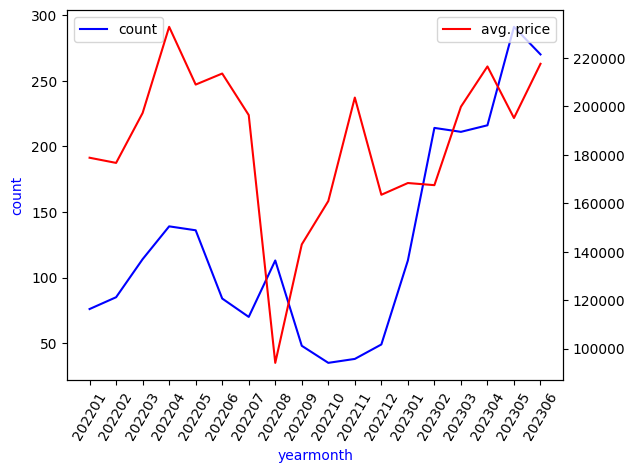

In [129]:
# figure와 왼쪽 y축용 axes 한 개 생성
fig, ax1 = plt.subplots()
# x축 눈금 위치와 라벨: 0,1,2,... 위치에 df_cnt.index(기준년월) 표시
ax1.set_xticks(np.arange(len(df_cnt.index)), labels=df_cnt.index)
# x축 이름(yearmonth), labelpad=여백, fontsize·color 지정
ax1.set_xlabel("yearmonth", loc="center", labelpad=5, fontsize=10, color="blue")
# 왼쪽 y축 이름(count) — 거래 건수
ax1.set_ylabel("count", labelpad=5, fontsize=10, color="blue")
# x축 라벨 60도 기울여 겹침 방지
ax1.tick_params(axis="x", labelrotation=60)
# 왼쪽 y축에 x1(거래 건수) 파란 선으로 그림
ax1.plot(x1, color="blue", label="count")
ax1.legend()
# 오른쪽 y축 생성 (같은 x축, 다른 y축 스케일 → 건수·평균금액 동시 표시)
ax2 = ax1.twinx()
# 오른쪽 y축에 x2(평균 거래금액) 빨간 선으로 그림
ax2.plot(x2, color="r", label="avg. price")
ax2.legend()
plt.show()

In [125]:
%pip install folium

  Obtaining dependency information for folium from https://files.pythonhosted.org/packages/b5/a8/5f764f333204db0390362a4356d03a43626997f26818a0e9396f1b3bd8c9/folium-0.20.0-py2.py3-none-any.whl.metadata
  Obtaining dependency information for branca>=0.6.0 from https://files.pythonhosted.org/packages/7e/50/fc9680058e63161f2f63165b84c957a0df1415431104c408e8104a3a18ef/branca-0.8.2-py3-none-any.whl.metadata
  Obtaining dependency information for jinja2>=2.9 from https://files.pythonhosted.org/packages/62/a1/3d680cbfd5f4b8f15abc1d571870c5fc3e594bb582bc3b64ea099db13e56/jinja2-3.1.6-py3-none-any.whl.metadata
  Obtaining dependency information for xyzservices from https://files.pythonhosted.org/packages/ef/5c/2c189d18d495dd0fa3f27ccc60762bbc787eed95b9b0147266e72bb76585/xyzservices-2025.11.0-py3-none-any.whl.metadata
  Obtaining dependency information for MarkupSafe>=2.0 from https://files.pythonhosted.org/packages/aa/5b/bec5aa9bbbb2c946ca2733ef9c4ca91c91b6a24580193e891b5f7dbe8e1e/markupsafe-3.0


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
